In [1]:
! pip install skrebate

  Preparing metadata (setup.py) ... done
  Created wheel for skrebate: filename=skrebate-0.62-py3-none-any.whl size=29253 sha256=003557bcc89d66e105e7d51452bc45d65322b40b09cff637488d489524a0c6e1
  Stored in directory: /root/.cache/pip/wheels/8a/d2/67/8368fca718041057b33d6448ca526aaf1ce2e404c94b901e41
Successfully built skrebate


## Imports

In [125]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
import matplotlib.pyplot as plt
from skrebate import ReliefF

## Loading data

In [3]:
data = pd.read_csv("cardio_data_cleaned(IQR).csv")

X = data.drop('cardio', axis = 1)
y = data['cardio']

## Relief algorithm for feature selection

In [54]:
sampled_data = data.sample(n=10000, random_state=42)

X_sampled = sampled_data.drop('cardio', axis=1)
y_sampled = sampled_data['cardio']

In [55]:
fs = ReliefF(
    n_neighbors=1,
    n_features_to_select=7,
    discrete_threshold=10,
    n_jobs=-1,
    verbose=False,
)
X_selected = fs.fit(X_sampled.to_numpy(), y_sampled.to_numpy())

In [56]:
selected_indices = fs.top_features_[:fs.n_features_to_select]
selected_feature_names = X.columns[selected_indices]
selected_feature_names = selected_feature_names.tolist()
print("Selected features:", selected_feature_names)

Selected features: ['MAP', 'cholesterol', 'age', 'BMI', 'gluc', 'smoke', 'active']


## Adding the gender feature to relief extracted features

In [57]:
selected_feature_names.append('gender')

In [58]:
X_relief = X.loc[:, selected_feature_names]

## Splitting the data (relief features) and training the RFBM

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X_relief, y, test_size=0.2, random_state=42
)

In [60]:
base_rf = RandomForestClassifier(random_state=42)
bagging_rf = BaggingClassifier(estimator=base_rf, random_state=42)
bagging_rf.fit(X_train, y_train)

BaggingClassifier(estimator=RandomForestClassifier(random_state=42),
                  random_state=42)

## Model evaluation (Relief features)

In [61]:
predictions = bagging_rf.predict(X_test)
cm = confusion_matrix(y_test, predictions)

In [62]:
cross_tab = pd.crosstab(y_test, predictions, rownames=['Actual'], colnames=['Predicted'])
cross_tab

Predicted,0,1
Actual,,
0,4887,1458
1,2061,4095


In [63]:
TN, FN, FP, TP = cm.ravel()

In [64]:
print('True Negatives:', TN)
print('False Negatives:', FN)
print('False Positives:', FP)
print('True Positives:', TP)

True Negatives: 4887
False Negatives: 1458
False Positives: 2061
True Positives: 4095


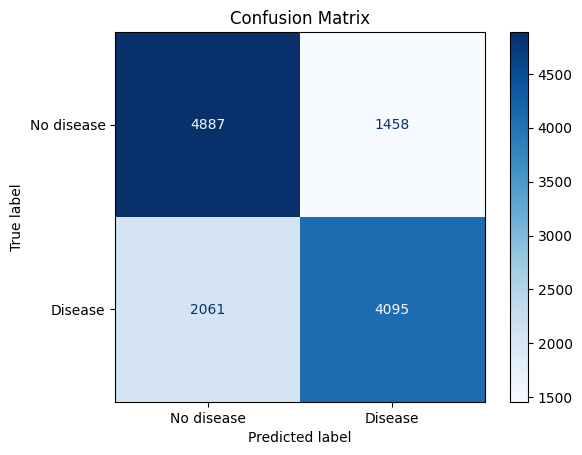

In [65]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No disease', 'Disease'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [66]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)
false_positive_rate = FP / (FP + TN)
false_negative_rate = FN / (FN + TP)
npv = TN / (TN + FN)

In [67]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1_score,
    "False Positive Rate": false_positive_rate,
    "False Negative Rate": false_negative_rate,
    "Negative Predictive Value": npv
}

In [68]:
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

Accuracy: 0.7185
Precision: 0.6652
Recall: 0.7374
F1-Score: 0.6995
False Positive Rate: 0.2966
False Negative Rate: 0.2626
Negative Predictive Value: 0.7702


## Feature selection using LASSO

In [128]:
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.001, random_state=42)
selector = SelectFromModel(lasso)

In [129]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [130]:
selector.fit(X_train, y_train)

SelectFromModel(estimator=LogisticRegression(C=0.001, penalty='l1',
                                             random_state=42,
                                             solver='liblinear'))

In [131]:
selected_indices = selector.get_support(indices=True)
selected_feature_names = X.columns[selected_indices]
selected_feature_names = selected_feature_names.tolist()
print("Selected features:", selected_feature_names)

Selected features: ['age', 'gender', 'cholesterol', 'active', 'MAP']


In [132]:
X_lasso = X.loc[:, selected_feature_names]

In [133]:
X_train, X_test, y_train, y_test = train_test_split(
    X_lasso, y, test_size=0.2, random_state=42
)

In [134]:
base_rf = RandomForestClassifier(random_state=42)
bagging_rf = BaggingClassifier(estimator=base_rf, random_state=42)
bagging_rf.fit(X_train, y_train)

BaggingClassifier(estimator=RandomForestClassifier(random_state=42),
                  random_state=42)

In [135]:
predictions = bagging_rf.predict(X_test)
cm = confusion_matrix(y_test, predictions)

In [136]:
cross_tab = pd.crosstab(y_test, predictions, rownames=['Actual'], colnames=['Predicted'])
cross_tab

Predicted,0,1
Actual,,
0,4843,1502
1,1965,4191


In [137]:
TN, FN, FP, TP = cm.ravel()

In [138]:
print('True Negatives:', TN)
print('False Negatives:', FN)
print('False Positives:', FP)
print('True Positives:', TP)

True Negatives: 4843
False Negatives: 1502
False Positives: 1965
True Positives: 4191


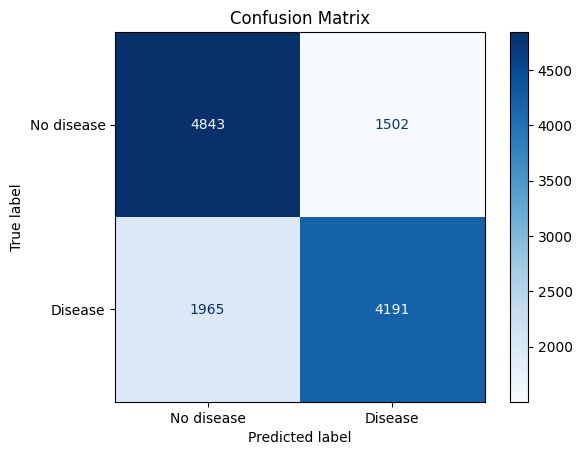

In [139]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No disease', 'Disease'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [140]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)
false_positive_rate = FP / (FP + TN)
false_negative_rate = FN / (FN + TP)
npv = TN / (TN + FN)

In [141]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1_score,
    "False Positive Rate": false_positive_rate,
    "False Negative Rate": false_negative_rate,
    "Negative Predictive Value": npv
}

In [142]:
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

Accuracy: 0.7227
Precision: 0.6808
Recall: 0.7362
F1-Score: 0.7074
False Positive Rate: 0.2886
False Negative Rate: 0.2638
Negative Predictive Value: 0.7633


## Complete feature set

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [86]:
base_rf = RandomForestClassifier(random_state=42)
bagging_rf = BaggingClassifier(estimator=base_rf, random_state=42)
bagging_rf.fit(X_train, y_train)

BaggingClassifier(estimator=RandomForestClassifier(random_state=42),
                  random_state=42)

In [87]:
predictions = bagging_rf.predict(X_test)
cm = confusion_matrix(y_test, predictions)

In [88]:
cross_tab = pd.crosstab(y_test, predictions, rownames=['Actual'], colnames=['Predicted'])
cross_tab

Predicted,0,1
Actual,,
0,4829,1516
1,2072,4084


In [89]:
TN, FN, FP, TP = cm.ravel()

In [90]:
print('True Negatives:', TN)
print('False Negatives:', FN)
print('False Positives:', FP)
print('True Positives:', TP)

True Negatives: 4829
False Negatives: 1516
False Positives: 2072
True Positives: 4084


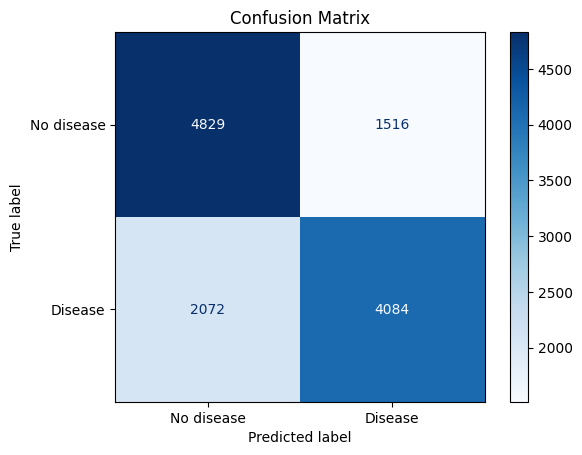

In [91]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No disease', 'Disease'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [92]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)
false_positive_rate = FP / (FP + TN)
false_negative_rate = FN / (FN + TP)
npv = TN / (TN + FN)

In [93]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1_score,
    "False Positive Rate": false_positive_rate,
    "False Negative Rate": false_negative_rate,
    "Negative Predictive Value": npv
}

In [94]:
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

Accuracy: 0.7130
Precision: 0.6634
Recall: 0.7293
F1-Score: 0.6948
False Positive Rate: 0.3002
False Negative Rate: 0.2707
Negative Predictive Value: 0.7611
